# Overview

This notebook evaluates the NMS-optimized detector's performance across multiple frames.

It computes key metrics (precision, recall, F1, accuracy), and assesses  localization and classification. Results are stored DataFrames for further analysis.

The evaluation Intersection over Union (eval-IoU) threshold can be adjusted and re-run the notebook with the desired value.

This notebook requires the `general` environment (kernel). See `./envs/README.md` for more information.

In [1]:
import os
import json
import time
import git
import numpy as np
import pandas as pd
# Import helper functions from model_performance_utils.py
from model_performance_utils import *

# Get the path to the project folder
prj_path = git.Repo('.', search_parent_directories=True).working_tree_dir
print(f"Root path of the project:\n'{prj_path}'")

Root path of the project:
'/scratch/vs66tavy/smartphone-insect-detect'


Set the evaluation IoU between a ground truth and a predicted box:

In [2]:
iou_threshold = 0.5 # or 0.1

# Read box data

## - Ground truth (GT)

In [3]:
file_path = os.path.join(prj_path, 'data', 'processed', 'df_roi.feather')
df_true = pd.read_feather(file_path)

df_true.sort_values(by=['new_filename', 'id_box'], inplace=True)
df_true.reset_index(drop=True, inplace=True)

In [4]:
# Define a mapping dictionary for naming the arthropod groups
rename_map = {
    "araneae":       "OtherT",
    "coleoptera":    "OtherT",
    "diptera":       "Diptera",
    "hemiptera":     "OtherT",
    "hymenoptera":   "Hymenoptera",
    "hymenoptera_f": "OtherT",
    "lepidoptera":   "OtherT",
    "orthoptera":    "OtherT"
}

df_true['true_group'] = df_true['p1_labels'].map(rename_map)

# Display value counts to verify
print(df_true[["true_group"]].value_counts())

true_group 
Hymenoptera    13412
OtherT          6401
Diptera         5025
Name: count, dtype: int64


## - Predictions (pred)

In [5]:
pred_json_file = os.path.join(prj_path, 'detectors', 'predictions', 'yolov5s', 
                              'conf_0.201918_iou_0.3.json')

with open(pred_json_file, 'r') as f:
    pred_json_data = json.load(f)

df_pred = pd.DataFrame([{
    "pred_image_id": item["image_id"],
    "new_filename": item["file_name"],
    "x": item["bbox"][0],
    "y": item["bbox"][1],
    "width": item["bbox"][2],
    "height": item["bbox"][3],
    "yolo_conf": item["score"],
    "yolo_label_id": item["category_id"]
} for item in pred_json_data])    

In [6]:
# Add the category name to predictions based on a mapping

label_dict = {
    0: 'araneae',
    1: 'coleoptera',
    2: 'diptera',
    3: 'hemiptera',
    4: 'hymenoptera_f',
    5: 'hymenoptera',
    6: 'lepidoptera',
    7: 'orthoptera'
}

groups_dict = {
    0: 'OtherT',
    1: 'OtherT',
    2: 'Diptera',
    3: 'OtherT',
    4: 'OtherT',
    5: 'Hymenoptera',
    6: 'OtherT',
    7: 'OtherT'
}

df_pred['yolo_label_name'] = df_pred['yolo_label_id'].map(label_dict)

df_pred['yolo_group'] = df_pred['yolo_label_id'].map(groups_dict)

df_pred[["yolo_group"]].value_counts()

yolo_group 
Hymenoptera    8735
Diptera        4547
OtherT         3638
Name: count, dtype: int64

# Instance (Box) Localization
This section describes the process of class-agnostic insect instance localization.

## Matching Ground Truths (GTs) to Predictions
The goal is to match GT boxes with predicted boxes based on the given eval-IoU, ignoring predicted labels.

IoU matching process:

- A predicted box can match multiple GT boxes, and vice versa.
- We aim to find the "best match" for each predicted box to each GT box.
- Keep predicted boxes with an IoU above eval-IoU for a given GT box.
- From these candidates, select the box with the highest YOLO confidence score.
- If a selected predicted box has already been assigned to a GT box, skip it to ensure each predicted box is assigned to at most one GT box.

Therefore:
- **True Positive (TP)**: a GT box matched to a predicted box above the eval-IoU threshold and with the highest YOLO confidence score (if multiple IoU matches exist).
- **False Negative (FN)**: a GT box not matched to any predicted box (model didn't localize successfully).
- **False Positive (FP)**: a predicted box not matched to any GT box (model hallucinates, overshoots / IoU is too low, or too many predictions for the same GT).


The `match_predictions_to_ground_truth()` function, imported from `model_performance_utils.py`, handles the GT-predictions matching:

- Calculates IoU between each GT box and predicted boxes for each image.
- If no IoU value exceeds the threshold for a GT box, assigns NaN to that GT row in `df_true` data frame to mark a FN.
- If at least one IoU value is above the eval-IoU threshold, selects the prediction with the highest YOLO confidence score and associates it with the GT box, marking a TP in `df_true`.
- "Free floating" predicted boxes not associated with any GT box are marked as FPs in `df_pred`. FPs can only be defined in `df_pred` as it contains all predictions.
- TPs and FNs are computed on the updated `df_true` (ground truth data frame) based on the matching information from `match_predictions_to_ground_truth()`. They cannot be defined on `df_pred` as it lacks information about all GTs.
- The `keep_seq == TRUE` filter (for TPs) excludes 182 background insects.

In [7]:
# Compute the 2nd corner of the boxes - needed for IoU calculations
df_true['x2'] = df_true['x'] + df_true['width']
df_true['y2'] = df_true['y'] + df_true['height']

df_pred['x2'] = df_pred['x'] + df_pred['width']
df_pred['y2'] = df_pred['y'] + df_pred['height']

In [8]:
start_time = time.time()

# This function modifies the df_true and df_pred DataFrames in place.
# It was imported from model_performance_utils.py
match_predictions_to_ground_truth(df_true, df_pred, iou_threshold)

end_time = time.time()
print(f"Process took {round((end_time - start_time) / 60, 1)} minutes.")
# ~ 2 min 

Process took 1.5 minutes.


In [9]:
# Compute FPs:

# FP is any extra predicted box that was not matched to a ground truth box.
# Must be computed on df_pred as it contains all the predictions.
df_pred['box_type'] = pd.Series(dtype='object') # Initialise with NaNs
mask_fp = (df_pred['idx_matched'] == False)
df_pred.loc[mask_fp, 'box_type'] = 'FP'


# Compute TPs and FNs:

# Initialise with NaNs
df_true['box_type'] = pd.Series(dtype='object')

# TP: GT box that was matched to a predicted one - note the .notnull()
mask_tp = df_true['pred_idx'].notnull()
df_true.loc[mask_tp, 'box_type'] = 'TP'

# FN: GT box without any match - note the .isnull()
mask_fn = df_true['pred_idx'].isnull()
df_true.loc[mask_fn, 'box_type'] = 'FN'

In [10]:
# One of the 182 background insects was detected, but all will be dropped from
# the analysis anyways.
# Filter for background insects
mask_background_insects = (df_true['keep_seq'] == False)
print(f"Number of background insects: {mask_background_insects.sum()}")
# And those that got a TP:
mask_bg_insect_tp = (df_true['keep_seq'] == False) & (df_true['box_type'] == 'TP')
count = mask_bg_insect_tp.sum()
print(f"Number of background insect TPs: {count}")
print( df_true.loc[mask_bg_insect_tp, ['id_raw', 'new_filename']] )

# I have also inspected the images with background insects and none of the FPs
# in df_pred are triggered by them (just 6 cases of FPs below, all "genuine"
# FPs)
# Get unique 'new_filename' values for background insects
unique_background_filenames = df_true.loc[mask_background_insects, 'new_filename'].unique()
# I visually checked these cases:
df_pred_check_bg_fps = df_pred[df_pred['new_filename'].isin(unique_background_filenames) & 
                               (df_pred['box_type'] == 'FP')]

# Finally, drop the background insects from df_true: keep only the rows with
# keep_seq = True
df_true = df_true[df_true['keep_seq'] == True]

Number of background insects: 182
Number of background insect TPs: 1
       id_raw        new_filename
20862   30859  img_crop_20034.jpg


In [11]:
# How many TP, FP, FN?
# The correct counts of TPs & FNs are the ones from df_true.
# The correct counts of FPs are the one from df_pred.
mask_fps = (df_pred['box_type'] == 'FP')
print(f"FP     {mask_fps.sum()}")
print(df_true['box_type'].value_counts(dropna=False))

FP     2265
box_type
TP    14654
FN    10002
Name: count, dtype: int64


In [12]:
tp = df_true['box_type'].value_counts(dropna=False)['TP']
fp = df_pred['box_type'].value_counts(dropna=False)['FP']
fn = df_true['box_type'].value_counts(dropna=False)['FN']

precision = tp / (tp + fp) # = from all predictions, how many are correct?
recall = tp / (tp + fn) # also known as true positive rate
# recall = from all ground truth boxes, how many were detected?
f1 = 2 * (precision * recall) / (precision + recall)

print("Overall box detection, irrespective of label")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"Precision: {round(precision, 3)}")
print(f"Recall: {round(recall, 3)}")
print(f"F1: {round(f1, 3)}")

# False positive as percent of total number of ground truth boxes.
n_rows_true = df_true.shape[0]
print(f"FP/N. ground truth boxes: {round(fp/n_rows_true, 4) * 100} %")

# Number of unique images from df_true
n_img = df_true['path'].nunique()
print(f"FP/N. images: {round(fp/n_img, 4) * 100} %")

print(f"tp + fp: {tp + fp}")
print(f"tp + fn: {tp + fn}") # = n_rows_true
print(f"N ground truth boxes: {n_rows_true} (must be equal with tp + fn)")

Overall box detection, irrespective of label
TP: 14654
FP: 2265
FN: 10002
Precision: 0.866
Recall: 0.594
F1: 0.705
FP/N. ground truth boxes: 9.19 %
FP/N. images: 9.48 %
tp + fp: 16919
tp + fn: 24656
N ground truth boxes: 24656 (must be equal with tp + fn)


## Instance localization performance metrics

Across instances, localization is, unsurprisingly, not that great for the taxa categories with small instances.

Defining localization across sequences and grouped taxa (OtherT) in the next section (with at least one instance localized), the results are a bit more optimistic.

Below there are statistics about False Positives (FPs) as well.

In [13]:
# Initialize an empty list to store results
results_list = []

dec = 4 # nr of decimals to round to

pred_labels = sorted(df_pred['yolo_label_name'].dropna().unique())

for label in pred_labels:
    group_gt = df_true[df_true['p1_labels'] == label]
    group_pred = df_pred[df_pred['yolo_label_name'] == label]
    tp = group_gt['box_type'].value_counts(dropna=False).get('TP', 0)
    fn = group_gt['box_type'].value_counts(dropna=False).get('FN', 0)
    fp = group_pred['box_type'].value_counts(dropna=False).get('FP', 0)
    
    precision, recall, f1 = compute_metrics_localization(tp, fp, fn)
    
    n_img = group_gt['new_filename'].nunique()
    n_rows = len(group_gt)
    
    # FPs per N. ground truths (instances)
    fp_per_n_gt = fp/n_rows if n_rows > 0 else 0.0
    # FPs per N. images
    fp_per_n_img = fp/n_img if n_img > 0 else 0.0
    
    # Append results to list as dictionaries
    results_list.append({
        'group': label,
        'N_rows': n_rows,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Precision': round(precision, dec),
        'Recall': round(recall, dec),
        'F1': round(f1, dec),
        'FP/N_gt': round(fp_per_n_gt, dec),
        'FP/N_img': round(fp_per_n_img, dec)
    })

# Convert list of dictionaries to DataFrame
df_box_summary = pd.DataFrame(results_list)

sums = df_box_summary[['N_rows', 'TP', 'FP', 'FN']].sum()
sums['group'] = 'Total'

# Calculate metrics for total row
# Compute overall precision and recall
sums['Precision'] = sums['TP'] / (sums['TP'] + sums['FP'])
sums['Recall'] = sums['TP'] / (sums['TP'] + sums['FN'])

# Compute overall F1
if (sums['Precision'] + sums['Recall']) > 0:
    sums['F1'] = 2 * (sums['Precision'] * sums['Recall']) / (sums['Precision'] + sums['Recall'])
else:
    sums['F1'] = 0.0

# Compute overall FPs per N. ground truths (instances) and per N. images
sums['FP/N_gt'] = sums['FP'] / sums['N_rows']
n_img_total = df_true['new_filename'].nunique()
print(f"Total number of unique images: {n_img_total}")
sums['FP/N_img'] = sums['FP'] / n_img_total

df_box_summary = pd.concat([df_box_summary, pd.DataFrame([sums])], ignore_index=True)

pd.set_option('display.precision', 4)
# display(df_box_summary)
print(df_box_summary.to_string())

Total number of unique images: 23899
           group  N_rows     TP    FP     FN  Precision  Recall      F1  FP/N_gt  FP/N_img
0        araneae    1036     48   145    988     0.2487  0.0463  0.0781   0.1400    0.1459
1     coleoptera    2778   1020   286   1758     0.7810  0.3672  0.4995   0.1030    0.1032
2        diptera    5018   3082   341   1936     0.9004  0.6142  0.7302   0.0680    0.0682
3      hemiptera     603     83    17    520     0.8300  0.1376  0.2361   0.0282    0.0282
4    hymenoptera   13254   9275   752   3979     0.9250  0.6998  0.7968   0.0567    0.0575
5  hymenoptera_f    1967   1146    74    821     0.9393  0.5826  0.7192   0.0376    0.0377
6    lepidoptera       0      0   621      0     0.0000  0.0000  0.0000   0.0000    0.0000
7     orthoptera       0      0    29      0     0.0000  0.0000  0.0000   0.0000    0.0000
8          Total   24656  14654  2265  10002     0.8661  0.5943  0.7049   0.0919    0.0948


In [14]:
# Sum of FP in df_box_summary must be the same as the overall fp computed above
print( sums['FP'] )
print( df_pred['box_type'].value_counts(dropna=False)['FP'] )

# Same for TP
print( sums['TP'] )
print( df_true['box_type'].value_counts(dropna=False)['TP'] )

# Same for FN
print( sums['FN'] )
print( df_true['box_type'].value_counts(dropna=False)['FN'] )

2265
2265
14654
14654
10002
10002


# Sequence (individual insect) localization

An individual insect was considered localized if it got at least one TP box across the consecutive frames in which it appears.

Compute for each category: Diptera, Hymenoptera, and OtherT.

In [15]:
# There are 1281 individual insects in the OOD dataset
total_seq_ids = df_true['seq_id'].nunique()
print(f"Unique sequences (individual insects): {total_seq_ids}")

Unique sequences (individual insects): 1281


In [16]:
# Compute the ratio of boxes detected for each seq_id

# Ratios dict will contain the seq_id as key and the ratio as value
ratios = {}
unique_seq_ids = df_true['seq_id'].unique()

for seq_id in unique_seq_ids:
    group = df_true[df_true['seq_id'] == seq_id]
    ratio = group['pred_iou'].notna().sum() / len(group)
    ratios[seq_id] = ratio

df_true['box_detected_ratio'] = df_true['seq_id'].map(ratios)

seq_ids_with_detected_boxes = df_true[df_true['box_detected_ratio'] > 0]['seq_id'].nunique()

ratio = round(seq_ids_with_detected_boxes / total_seq_ids, 3)

print(f"Nr. seq_id with at least 1 box detected (box_detected_ratio > 0): {seq_ids_with_detected_boxes}")
print(f"Proportion seq_id detected: {ratio}")

Nr. seq_id with at least 1 box detected (box_detected_ratio > 0): 1110
Proportion seq_id detected: 0.867


In [17]:
total_counts = df_true.groupby('true_group')['seq_id'].nunique()
detected_counts = df_true[df_true['box_detected_ratio'] > 0].groupby('true_group')['seq_id'].nunique()
proportions = detected_counts / total_counts

# Create a dataframe to present the results.
# In this case any detected individual is TP and any undetected individual is FN.
# Recall = TP/(TP+FN) = TP/Total indiv. = proportion of detected individuals.
result_loc_df = pd.DataFrame({'N indiv.': total_counts, 
                              'TP': detected_counts,
                              'FN': total_counts - detected_counts, 
                              'Localization rate (recall), %': round(proportions * 100, 2)})

result_loc_df = result_loc_df.sort_values(by='N indiv.', ascending=False)
print(result_loc_df)

             N indiv.   TP  FN  Localization rate (recall), %
true_group                                                   
Hymenoptera      1013  924  89                          91.21
Diptera           145  117  28                          80.69
OtherT            123   69  54                          56.10


# Classification

Check if the predicted label matches the ground truth label.

"Max. confidence" rule = if a sequence has multiple predicted TP boxes, then the final predicted label is the one with the highest confidence score.

In [18]:
# Initialize a dictionary to store the label and the row ID of the max
# confidence prediction for each seq_id
label_and_row_id = {}

for seq_id, group in df_true.groupby('seq_id'):
    non_null_group = group.dropna(subset=['pred_conf'])
    if len(non_null_group) > 0:
        # Get the index of the row with the maximum prediction confidence
        max_conf_idx = non_null_group['pred_conf'].idxmax()
        # Get the label associated with the maximum prediction confidence
        max_conf_label = non_null_group.loc[max_conf_idx, 'pred_label']
        # Store the label and the row ID (index) in the dictionary
        label_and_row_id[seq_id] = (max_conf_label, max_conf_idx)

# Map the label to each row based on seq_id
df_true['common_label'] = df_true['seq_id'].map(lambda x: label_and_row_id[x][0] if x in label_and_row_id else None)

# Create a new column to mark the row with the maximum prediction confidence
# within each sequence group.
# Initially set all values to False
df_true['is_max_conf_row'] = False
# Mark the row with the maximum prediction confidence as True
for seq_id, row_id in label_and_row_id.values():
    df_true.at[row_id, 'is_max_conf_row'] = True

In [19]:
# Mark if the label was matched or not.
# It will return NaN when encounters NaN values in pred_label
df_true['label_matched'] = np.where(df_true['pred_label'].isnull(), 
                                    np.nan, 
                                    df_true['pred_label'] == df_true['p1_labels'])

In [20]:
# Define data frame with ground truths and predicted labels per individual
# insect (sequence).
cols = ['seq_id','p1_labels', 'common_label', 'true_group']
df_seq = df_true[cols].drop_duplicates(cols)

# Apply mapping to df_true
df_seq['yolo_group'] = df_seq['common_label'].map(rename_map)

# Display value counts to verify
print(df_seq[["true_group"]].value_counts())

true_group 
Hymenoptera    1013
Diptera         145
OtherT          123
Name: count, dtype: int64


## Confusion matrices

Confusion matrix: Not normalized (counts)
[[815  86  23  89]
 [ 11  97   9  28]
 [  8   2  59  54]
 [  0   0   0   0]] 

Confusion matrix: Normalized by 'true' (rows), Recall
[[0.8045 0.0849 0.0227 0.0879]
 [0.0759 0.669  0.0621 0.1931]
 [0.065  0.0163 0.4797 0.439 ]
 [0.     0.     0.     0.    ]] 

Confusion matrix: Normalized by 'pred' (cols), Precision
[[0.9772 0.4649 0.2527 0.5205]
 [0.0132 0.5243 0.0989 0.1637]
 [0.0096 0.0108 0.6484 0.3158]
 [0.     0.     0.     0.    ]] 



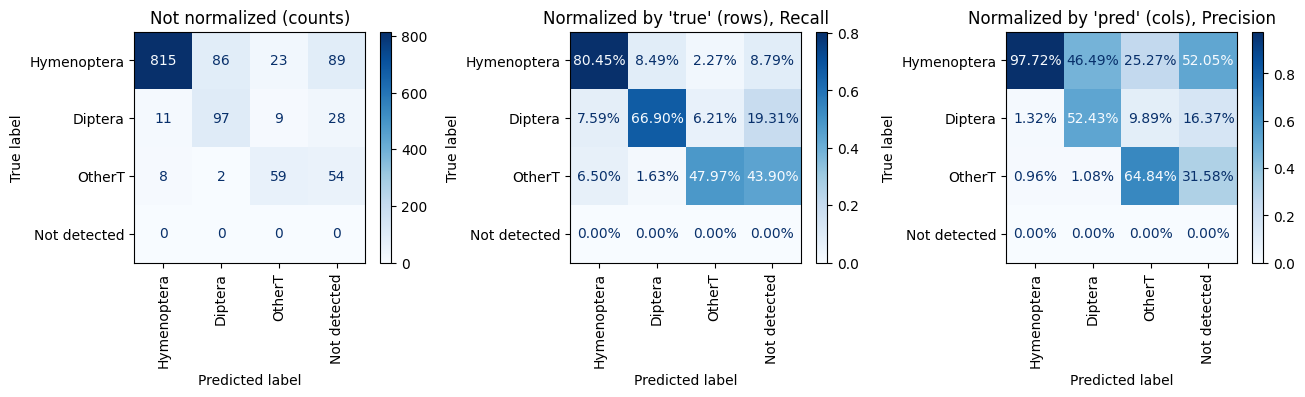

In [21]:
# Get the ground truth and predicted labels for the groups
y_true = df_seq['true_group'].astype(str).to_numpy()
y_pred = df_seq['yolo_group'].astype(str).to_numpy()

# Replace NaN values in y_pred
y_pred = np.where(y_pred == 'nan', 'Not detected', y_pred)

# Define order of labels to appear in the graphs
group_labels = ['Hymenoptera', 'Diptera', 'OtherT', 'Not detected']

# Define titles and normalization options
normalization_options = [
    ("Not normalized (counts)", None),
    ("Normalized by 'true' (rows), Recall", "true"),
    ("Normalized by 'pred' (cols), Precision", "pred")
]

# Set nr. of digits for printing the confusion matrices in the console.
np.set_printoptions(precision=4)

# Create a matplotlib figure and axis for side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

# Iterate over the options and plot in the subplots
for ax, (title, normalize) in zip(axes, normalization_options):
    # Compute the confusion matrix with or without normalization
    cm = confusion_matrix(y_true, y_pred, normalize=normalize, labels=group_labels)
    # Plot the matrices also in the console
    print(f"Confusion matrix: {title}")
    print(cm, "\n")
    
    # Determine the format for values based on normalization
    values_format = '.2%' if normalize else 'd'
    # Set the title for each subplot
    ax.set_title(title)
    # Create and plot the confusion matrix, specifying the target subplot
    disp = ConfusionMatrixDisplay(cm, display_labels=group_labels)
    disp.plot(ax=ax, 
              cmap=plt.cm.Blues, 
              values_format=values_format,
              xticks_rotation='vertical')

plt.subplots_adjust(wspace=0.5, hspace=0)

## Performance metrics

The higher accuracy and specificity (also known as True Negative Rate - TNR) for the "OtherT" group is due to the higher number of TNs for this group.

It also suggests that the classifier component is good at identifying what doesn't belong to the "OtherT" group, leading to fewer false positives for this group. So, the classifier is not confusing Hymenoptera and Diptera with the "OtherT" group, which corresponds to the expectation that "OtherT" is distinct and the model confuses Hymenoptera with Diptera, but not that much with "OtherT". 

In [22]:
result_df = compute_metrics_classification(df_seq, df_true, 
                                           gt_label_col='true_group', 
                                           pred_label_col='yolo_group', 
                                           dec=4)
pd.set_option('display.precision', 4)
print(result_df.to_string(index=True))

      Category  N.box  N.insect  N.insect%  N.detected   TP   FP   FN    TN  Precision  Recall      F1  Accuracy  Specificity
0  Hymenoptera  13254      1013      79.08         924  815   19  198   249     0.9772  0.8045  0.8825    0.8306       0.9291
1      Diptera   5018       145      11.32         117   97   88   48  1048     0.5243  0.6690  0.5879    0.8938       0.9225
2       OtherT   6384       123       9.60          69   59   32   64  1126     0.6484  0.4797  0.5514    0.9251       0.9724
3        Total  24656      1281     100.00        1110  971  139  310  2423     0.8944  0.7580  0.8205    0.8468       0.9325


# Save results

Table for manuscript. See also the confusion matrix values above (counts and normalization by ground truths, resulting in recall value son the diagonal)

In [23]:
# Rest index
tbl_df = result_df.reset_index(drop=True)

# Compute detection rate = N.detected / N.seq.
tbl_df['Loc-Recall'] = round(tbl_df['N.detected'] / tbl_df['N.insect'], 4)

# Keep only these columns: Category, N.seq., N.detected, Precision, Recall/TPR/Sensitivity, F1
cols_to_keep = ['Category', 'N.insect', 'N.detected', 'Loc-Recall', 'Precision', 'Recall', 'F1', 'Accuracy']
tbl_df = tbl_df[cols_to_keep]

# Save to CSV file for manuscript
filename = f'Table_yolov5s_metrics_iou_{iou_threshold}.csv'
file_path = os.path.join(prj_path, 'results', 'tables', filename)
tbl_df.to_csv(file_path, index=False)

print(tbl_df.to_string(index=True))

      Category  N.insect  N.detected  Loc-Recall  Precision  Recall      F1  Accuracy
0  Hymenoptera      1013         924      0.9121     0.9772  0.8045  0.8825    0.8306
1      Diptera       145         117      0.8069     0.5243  0.6690  0.5879    0.8938
2       OtherT       123          69      0.5610     0.6484  0.4797  0.5514    0.9251
3        Total      1281        1110      0.8665     0.8944  0.7580  0.8205    0.8468


Data frames for further analysis

In [24]:
# Table with TPs and FNs:
filename = f'df_eval_seq_yolov5s_iou_{iou_threshold}.feather'
file_path = os.path.join(prj_path, 'data', 'processed', filename)
df_true.reset_index(drop=True).to_feather(file_path)

# Table with FPs:
filename = f'df_pred_seq_yolov5s_iou_{iou_threshold}.feather'
file_path = os.path.join(prj_path, 'data', 'processed', filename)
df_pred.reset_index(drop=True).to_feather(file_path)